(np.float64(0.0), np.float64(6.0), np.float64(0.0), np.float64(20.0))

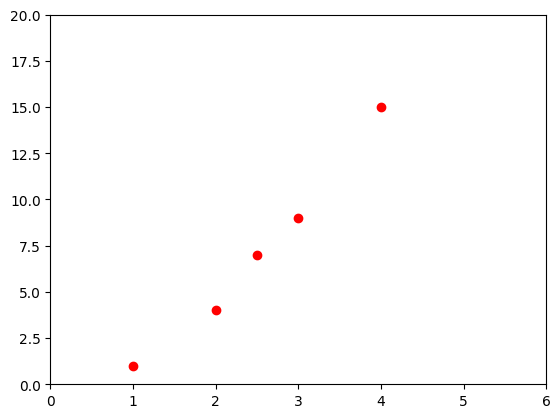

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = [1, 2, 2.5, 3, 4]
y = [1, 4, 7, 9, 15]
plt.plot(x, y, 'ro')
plt.axis([0, 6, 0, 20])

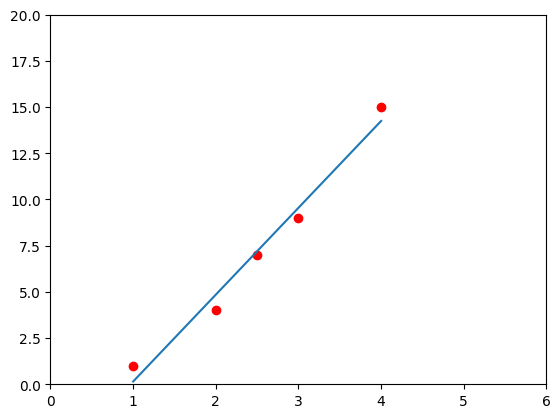

In [2]:
plt.plot(x, y, 'ro')
plt.axis([0, 6, 0, 20])
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))
plt.show()

In [3]:
from __future__ import absolute_import, division, print_function, unicode_literals

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from six.moves import urllib

import tensorflow.compat.v2.feature_column as fc

import tensorflow as tf

In [4]:
# Load dataset.
import tensorflow as tf
import pandas as pd

dftrain = pd.read_csv(r"C:\Users\Acer_Nitro\Downloads\train.csv")
dfeval = pd.read_csv(r"C:\Users\Acer_Nitro\Downloads\test.csv")

In [5]:
dftrain = pd.read_csv(r"C:\Users\Acer_Nitro\Downloads\train.csv")
print(dftrain.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
y_train = dftrain.pop('Survived')

In [7]:
dftrain.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
dftrain.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
dftrain.shape

(891, 11)

In [10]:
dftrain = pd.read_csv(r"C:\Users\Acer_Nitro\Downloads\train.csv")
y_train = dftrain.pop('Survived')
print(y_train.head())

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


<Axes: >

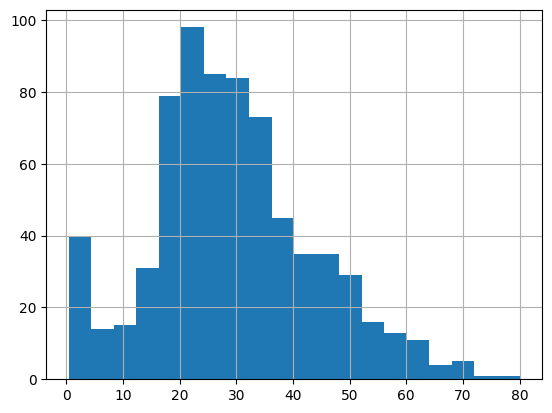

In [11]:
dftrain.Age.hist(bins=20)

<Axes: ylabel='Sex'>

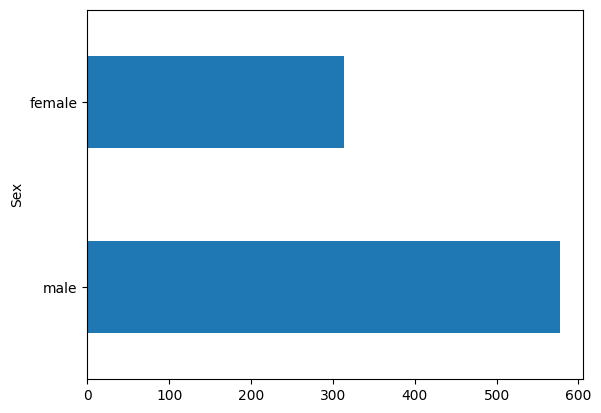

In [12]:
dftrain.Sex.value_counts().plot(kind='barh')

<Axes: ylabel='Pclass'>

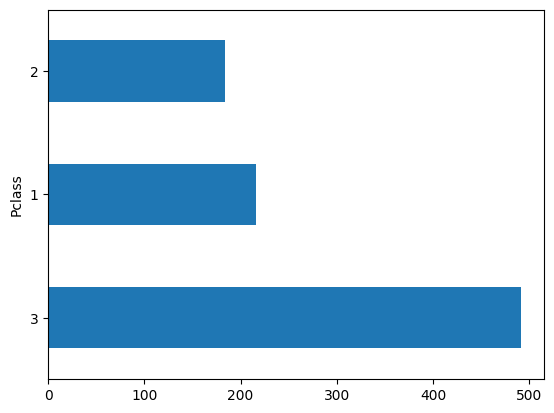

In [13]:
dftrain['Pclass'].value_counts().plot(kind='barh')

Text(0.5, 0, '% Survive')

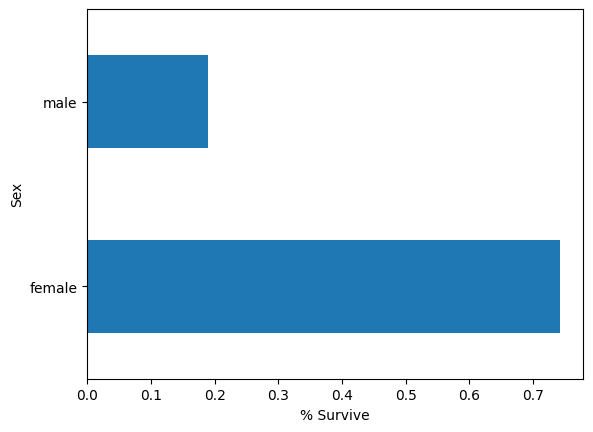

In [14]:
pd.concat([dftrain, y_train], axis=1).groupby('Sex').Survived.mean().plot(kind='barh').set_xlabel('% Survive')

In [15]:
CATEGORICAL_COLUMNS = ['Sex','Embarked', 'Pclass']
NUMERIC_COLUMNS = ['Age', 'Fare', 'SibSp', 'Parch']

feature_columns = []
for feature_name in CATEGORICAL_COLUMNS:
  vocabulary = dftrain[feature_name].unique()  
  feature_columns.append(tf.feature_column.categorical_column_with_vocabulary_list(feature_name, vocabulary))

for feature_name in NUMERIC_COLUMNS:
  feature_columns.append(tf.feature_column.numeric_column(feature_name, dtype=tf.float32))

print(feature_columns)

Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.
Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.
[VocabularyListCategoricalColumn(key='Sex', vocabulary_list=('male', 'female'), dtype=tf.string, default_value=-1, num_oov_buckets=0), VocabularyListCategoricalColumn(key='Embarked', vocabulary_list=('S', 'C', 'Q', nan), dtype=tf.string, default_value=-1, num_oov_buckets=0), VocabularyListCategoricalColumn(key='Pclass', vocabulary_list=(np.int64(3), np.int64(1), np.int64(2)), dtype=tf.int64, default_value=-1, num_oov_buckets=0), NumericColumn(key='Age', shape=(1

In [16]:
dftrain_backup = pd.read_csv(r"C:\Users\Acer_Nitro\Downloads\train.csv")
dftrain = dftrain_backup.copy()

In [17]:
from sklearn.model_selection import train_test_split

y = dftrain.pop('Survived')

X_train, X_eval, y_train, y_eval = train_test_split(dftrain, y, test_size=0.2, random_state=42)

In [18]:
def make_input_fn(data_df, label_df, num_epochs=10, shuffle=True, batch_size=32):
  def input_function(): 
    ds = tf.data.Dataset.from_tensor_slices((dict(data_df), label_df))  
    if shuffle:
      ds = ds.shuffle(1000)  
    ds = ds.batch(batch_size).repeat(num_epochs) 
    return ds 
  return input_function  

train_input_fn = make_input_fn(dftrain, y_train) 
eval_input_fn = make_input_fn(dfeval, y_eval, num_epochs=1, shuffle=False)

In [19]:
dftrain_backup = pd.read_csv(r"C:\Users\Acer_Nitro\Downloads\train.csv")
dftrain = dftrain_backup.copy()

In [20]:
dftrain['Age'].fillna(dftrain['Age'].mean(), inplace=True)
dftrain['Fare'].fillna(dftrain['Fare'].mean(), inplace=True)

dftrain['Sex'] = dftrain['Sex'].map({'male':0,'female':1})
dftrain['Embarked'] = dftrain['Embarked'].map({'S':0,'C':1,'Q':2})
dftrain['Embarked'].fillna(0, inplace=True)

y_train_full = dftrain.pop('Survived')

C:\Users\Acer_Nitro\AppData\Local\Temp\ipykernel_14584\3121565411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dftrain['Age'].fillna(dftrain['Age'].mean(), inplace=True)
C:\Users\Acer_Nitro\AppData\Local\Temp\ipykernel_14584\3121565411.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    dftrain, y, test_size=0.2, random_state=42
)

numeric_features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]

In [22]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_num, y_train, epochs=20, batch_size=32, verbose=0)

accuracy = model.evaluate(X_test_num, y_test, verbose=0)[1]
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.3352


In [23]:
linear_est = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(7,))  
])
linear_est.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

D:\Anaconda\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
linear_est.fit(X_train_num, y_train, epochs=20, batch_size=32, verbose=0)

accuracy = linear_est.evaluate(X_test_num, y_test, verbose=0)[1]
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.3631


D:\Anaconda\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


<Axes: title={'center': 'predicted probabilities'}, ylabel='Frequency'>

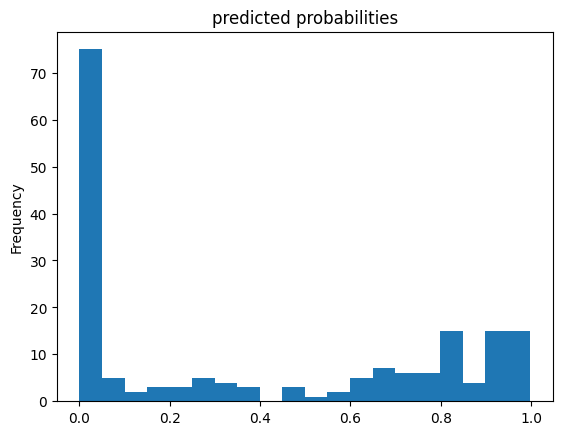

In [25]:
numeric_features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']

X_train_num = X_train[numeric_features].fillna(0)
X_test_num  = X_test[numeric_features].fillna(0)

linear_est = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train_num.shape[1],))
])
linear_est.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
linear_est.fit(X_train_num, y_train, epochs=20, batch_size=32, verbose=0)

probs = linear_est.predict(X_test_num)
probs = pd.Series(probs.flatten())

probs.plot(kind='hist', bins=20, title='predicted probabilities')

In [26]:
from __future__ import absolute_import, division, print_function, unicode_literals

import tensorflow as tf

import pandas as pd

In [27]:
CSV_COLUMN_NAMES = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Species']
SPECIES = ['Setosa', 'Versicolor', 'Virginica']

In [28]:
train_path = tf.keras.utils.get_file(
    "iris_training.csv", "https://storage.googleapis.com/download.tensorflow.org/data/iris_training.csv")
test_path = tf.keras.utils.get_file(
    "iris_test.csv", "https://storage.googleapis.com/download.tensorflow.org/data/iris_test.csv")

train = pd.read_csv(train_path, names=CSV_COLUMN_NAMES, header=0)
test = pd.read_csv(test_path, names=CSV_COLUMN_NAMES, header=0)

In [29]:
train.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,6.4,2.8,5.6,2.2,2
1,5.0,2.3,3.3,1.0,1
2,4.9,2.5,4.5,1.7,2
3,4.9,3.1,1.5,0.1,0
4,5.7,3.8,1.7,0.3,0


In [30]:
train_y = train.pop('Species')
test_y = test.pop('Species')
train.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,6.4,2.8,5.6,2.2
1,5.0,2.3,3.3,1.0
2,4.9,2.5,4.5,1.7
3,4.9,3.1,1.5,0.1
4,5.7,3.8,1.7,0.3


In [31]:
train.shape

(120, 4)

In [32]:
# Input Function

def input_fn(features, labels, training=True, batch_size=256):
    dataset = tf.data.Dataset.from_tensor_slices((dict(features), labels))
    if training:
        dataset = dataset.shuffle(1000).repeat() 
    return dataset.batch(batch_size)

In [33]:
# Feature Columns

my_feature_columns = []
for key in train.keys():
    my_feature_columns.append(tf.feature_column.numeric_column(key=key))
print(my_feature_columns)

[NumericColumn(key='SepalLength', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='SepalWidth', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PetalLength', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PetalWidth', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None)]


In [34]:
dftrain_backup = pd.read_csv(r"C:\Users\Acer_Nitro\Downloads\train.csv")
dftrain = dftrain_backup.copy()

In [35]:
y_train = dftrain['Survived']    
X_train = dftrain.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin'])  

X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_train['Embarked'] = X_train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
X_train = X_train.fillna(0)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf

dftrain = pd.read_csv(r"C:\Users\Acer_Nitro\Downloads\train.csv")  
y = dftrain['Survived']
X = dftrain.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin'])

X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X['Embarked'] = X['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

accuracy = model.evaluate(X_test, y_test, verbose=0)[1]
print("Accuracy:", round(accuracy, 4))

Epoch 1/20


D:\Anaconda\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5351 - loss: 6.6917 
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5126 - loss: 1.9557
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5014 - loss: 1.1094 
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5871 - loss: 0.8778
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5815 - loss: 0.7878 
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5632 - loss: 0.7843
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6081 - loss: 0.7074
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6096 - loss: 0.7335
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6362 - loss: 0.6931
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6433 - loss: 0.6693
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5927 - loss: 0.7087
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6320 - loss: 0.74

In [37]:
dftrain_backup = pd.read_csv(r"C:\Users\Acer_Nitro\Downloads\train.csv")
dftrain = dftrain_backup.copy()

In [38]:
classifier = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

classifier.fit(X_train, y_train, epochs=20, batch_size=32)
accuracy = classifier.evaluate(X_test, y_test)[1]
print("Accuracy:", round(accuracy, 4))

classifier.train(
    input_fn=lambda: input_fn(train, train_y, training=True),
    steps=5000)

Epoch 1/20


D:\Anaconda\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4733 - loss: 7.5245
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4565 - loss: 5.4234
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4789 - loss: 3.7063
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5154 - loss: 2.0835
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5716 - loss: 1.0354
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6713 - loss: 0.7104
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6222 - loss: 0.7707
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6699 - loss: 0.6593
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7135 - loss: 0.5778
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6980 - loss: 0.6040
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6756 - loss: 0.6416
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5997 - loss: 0.8717 

AttributeError: 'Sequential' object has no attribute 'train'

In [39]:
y = dftrain['Survived']
X = dftrain.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin'])
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X['Embarked'] = X['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = tf.keras.Sequential([tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],))])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)
accuracy = model.evaluate(X_test, y_test, verbose=0)[1]
print("Accuracy:", round(accuracy, 4))
probs = model.predict(X_test).flatten()

Epoch 1/20


D:\Anaconda\envs\tf\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4199 - loss: 24.4682
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4340 - loss: 17.9720
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4522 - loss: 12.1016
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4874 - loss: 7.2837
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5267 - loss: 4.8790
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5576 - loss: 4.3087
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5576 - loss: 4.1306
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5576 - loss: 3.9788
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5632 - loss: 3.8365
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5688 - loss: 3.6882
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5674 - loss: 3.5467
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5702 - loss: 3.41

In [40]:
eval_result = classifier.evaluate(X_test, y_test)
print("\nTest set accuracy: {:.3f}\n".format(eval_result[1]))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7095 - loss: 0.5627 

Test set accuracy: 0.709



In [41]:
predict = {
    'Pclass': [3],
    'Sex': [0],
    'Age': [29],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': [0]
}

predict_full = {}
for col in X_train.columns:
    if col in predict:
        predict_full[col] = predict[col]
    else:
        predict_full[col] = [0]  

predict_array = np.array([predict_full[col][0] for col in X_train.columns]).reshape(1, -1)

In [42]:
expected = ['Setosa', 'Versicolor', 'Virginica']
predict_x = {
    'SepalLength': [5.1, 5.9, 6.9],
    'SepalWidth': [3.3, 3.0, 3.1],
    'PetalLength': [1.7, 4.2, 5.4],
    'PetalWidth': [0.5, 1.5, 2.1],
}

In [43]:
import tensorflow as tf
import tensorflow_probability as tfp

tfd = tfp.distributions  
initial_distribution = tfd.Categorical(probs=[0.2, 0.8])  
transition_distribution = tfd.Categorical(probs=[[0.5, 0.5],
                                                 [0.2, 0.8]])  
observation_distribution = tfd.Normal(loc=[0., 15.], scale=[5., 10.]) 

In [44]:
model = tfd.HiddenMarkovModel(
    initial_distribution=initial_distribution,
    transition_distribution=transition_distribution,
    observation_distribution=observation_distribution,
    num_steps=7)

In [45]:
mean = model.mean()